# Multi-Asset Portfolio Risk Analysis

## Research Question

How does diversification across asset classes affect the historical
risk and return characteristics of a portfolio?

### Secondary Question

How do differences in the correlations between asset returns
contribute to portfolio diversification?

## Asset Selection

This analysis uses five exchange-traded funds (ETFs) representing
different market exposures:

| Ticker | Exposure |
|---|---|
| SPY | U.S. large-cap equities |
| QQQ | Nasdaq-100 equities |
| VXUS | International equities excluding the U.S. |
| IEF | U.S. Treasury bonds |
| GLD | Gold |

The assets were selected to provide a mixture of equity, fixed-income,
international, and alternative-asset exposures for examining historical
portfolio diversification.

## Analysis Period

The analysis covers January 1, 2020 through December 31, 2025 using
historical daily market data.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

In [3]:
tickers = ["SPY", "QQQ", "VXUS", "IEF", "GLD"]

start_date = "2020-01-01"
end_date = "2026-01-01"

In [4]:
raw_data = yf.download(
    tickers,
    start=start_date,
    end=end_date,
    auto_adjust=False,
    progress=False
)

In [5]:
raw_data.head()

Price        Adj Close                                                \
Ticker             GLD        IEF         QQQ         SPY       VXUS   
Date                                                                   
2020-01-02  143.949997  93.721695  207.872284  295.391754  46.430744   
2020-01-03  145.860001  94.348076  205.968170  293.155029  45.861794   
2020-01-06  147.389999  94.246460  207.295273  294.273438  45.927769   
2020-01-07  147.970001  94.111061  207.266418  293.445923  45.845314   
2020-01-08  146.860001  93.891022  208.824280  295.009918  45.927769   

Price            Close                                                 ...  \
Ticker             GLD         IEF         QQQ         SPY       VXUS  ...   
Date                                                                   ...   
2020-01-02  143.949997  110.730003  216.160004  324.869995  56.310001  ...   
2020-01-03  145.860001  111.470001  214.179993  322.410004  55.619999  ...   
2020-01-06  147.389999  111.349998  215.559998  323.640015  55.700001  ...   
2020-01-07  147.970001  111.190002  215.529999  322.730011  55.599998  ...   
2020-01-08  146.860001  110.930000  217.149994  324.450012  55.700001  ...   

Price             Open                                                 \
Ticker             GLD         IEF         QQQ         SPY       VXUS   
Date                                                                    
2020-01-02  143.860001  110.690002  214.399994  323.540009  56.169998   
2020-01-03  145.750000  111.150002  213.300003  321.160004  55.590000   
2020-01-06  148.440002  111.660004  212.500000  320.489990  55.419998   
2020-01-07  147.570007  111.330002  215.639999  323.019989  55.740002   
2020-01-08  148.490005  111.290001  215.500000  322.940002  55.590000   

Price         Volume                                        
Ticker           GLD      IEF       QQQ       SPY     VXUS  
Date                                                        
2020-01-02   7733800  4022300  30969400  59151200  2017900  
2020-01-03  12272800  3839600  27518900  77709700  2140200  
2020-01-06  14403300  2714300  21655300  55653900  2119900  
2020-01-07   7978500  2038800  22139300  40496400  1987300  
2020-01-08  22248500  5081100  26397300  68296000  1824400  

[5 rows x 30 columns]

In [6]:
raw_data.shape

(1508, 30)

In [7]:
raw_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1508 entries, 2020-01-02 to 2025-12-31
Data columns (total 30 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Adj Close, GLD)   1508 non-null   float64
 1   (Adj Close, IEF)   1508 non-null   float64
 2   (Adj Close, QQQ)   1508 non-null   float64
 3   (Adj Close, SPY)   1508 non-null   float64
 4   (Adj Close, VXUS)  1508 non-null   float64
 5   (Close, GLD)       1508 non-null   float64
 6   (Close, IEF)       1508 non-null   float64
 7   (Close, QQQ)       1508 non-null   float64
 8   (Close, SPY)       1508 non-null   float64
 9   (Close, VXUS)      1508 non-null   float64
 10  (High, GLD)        1508 non-null   float64
 11  (High, IEF)        1508 non-null   float64
 12  (High, QQQ)        1508 non-null   float64
 13  (High, SPY)        1508 non-null   float64
 14  (High, VXUS)       1508 non-null   float64
 15  (Low, GLD)         1508 non-null   float64
 16  (Low, IEF)       

In [8]:
prices = raw_data["Adj Close"].copy()

In [9]:
prices.head()

Ticker,GLD,IEF,QQQ,SPY,VXUS
Date,,,,,
2020-01-02,143.949997,93.721695,207.872284,295.391754,46.430744
2020-01-03,145.860001,94.348076,205.968170,293.155029,45.861794
2020-01-06,147.389999,94.246460,207.295273,294.273438,45.927769
2020-01-07,147.970001,94.111061,207.266418,293.445923,45.845314
2020-01-08,146.860001,93.891022,208.824280,295.009918,45.927769


In [10]:
prices.tail()

Ticker,GLD,IEF,QQQ,SPY,VXUS
Date,,,,,
2025-12-24,411.929993,93.836914,621.812256,685.029480,75.057571
2025-12-26,416.739990,93.924568,621.772461,684.959961,75.295815
2025-12-29,398.600006,94.060921,618.762634,682.519043,75.057571
2025-12-30,398.890015,93.963524,617.327515,681.685608,75.206467
2025-12-31,396.309998,93.651871,612.224915,676.635010,74.888817


In [11]:
prices.isna().sum()

Ticker
GLD     0
IEF     0
QQQ     0
SPY     0
VXUS    0
dtype: int64

In [12]:
prices.to_csv("../data/adjusted_close_prices.csv")

In [13]:
prices.plot(figsize=(12, 6))

plt.title("Historical Adjusted Prices")
plt.xlabel("Date")
plt.ylabel("Adjusted Price (USD)")
plt.tight_layout()
plt.show()

<Figure size 1200x600 with 1 Axes>

In [14]:
daily_returns = prices.pct_change()

In [15]:
daily_returns.head()

Ticker,GLD,IEF,QQQ,SPY,VXUS
Date,,,,,
2020-01-02,NaN,NaN,NaN,NaN,NaN
2020-01-03,0.013269,0.006683,-0.009160,-0.007572,-0.012254
2020-01-06,0.010490,-0.001077,0.006443,0.003815,0.001439
2020-01-07,0.003935,-0.001437,-0.000139,-0.002812,-0.001795
2020-01-08,-0.007502,-0.002338,0.007516,0.005330,0.001799


In [16]:
daily_returns = daily_returns.dropna()

In [17]:
daily_returns.head()

Ticker,GLD,IEF,QQQ,SPY,VXUS
Date,,,,,
2020-01-03,0.013269,0.006683,-0.009160,-0.007572,-0.012254
2020-01-06,0.010490,-0.001077,0.006443,0.003815,0.001439
2020-01-07,0.003935,-0.001437,-0.000139,-0.002812,-0.001795
2020-01-08,-0.007502,-0.002338,0.007516,0.005330,0.001799
2020-01-09,-0.005652,0.000721,0.008474,0.006780,0.004488


In [18]:
prices["SPY"].head()

Date
2020-01-02    295.391754
2020-01-03    293.155029
2020-01-06    294.273438
2020-01-07    293.445923
2020-01-08    295.009918
Name: SPY, dtype: float64

In [19]:
daily_returns.describe()

Ticker,GLD,IEF,QQQ,SPY,VXUS
count,1507.000000,1507.000000,1507.000000,1507.000000,1507.000000
mean,0.000725,0.000011,0.000844,0.000636,0.000390
std,0.010295,0.004801,0.015945,0.013070,0.012007
min,-0.064269,-0.025073,-0.119788,-0.109424,-0.111318
25%,-0.004662,-0.002840,-0.006686,-0.004845,-0.005371
50%,0.000842,0.000000,0.001415,0.000973,0.000814
75%,0.006315,0.002725,0.009113,0.006834,0.006452
max,0.048530,0.026416,0.120031,0.105019,0.083809


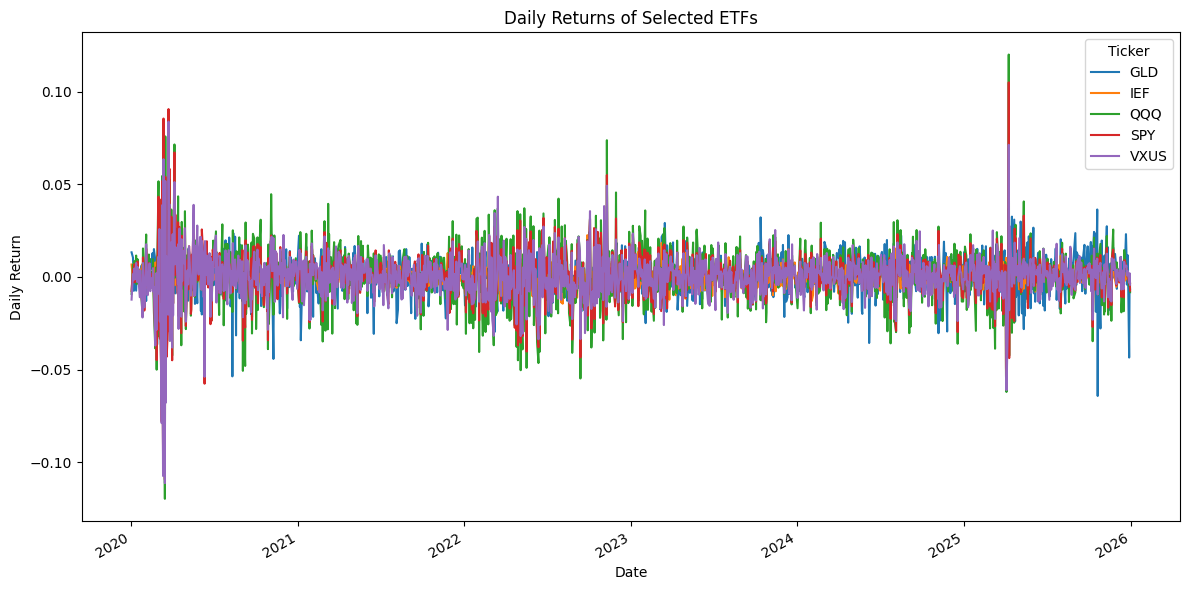

In [20]:
daily_returns.plot(figsize=(12, 6))

plt.title("Daily Returns of Selected ETFs")
plt.xlabel("Date")
plt.ylabel("Daily Return")
plt.tight_layout()
plt.show()

In [21]:
cumulative_returns = (1 + daily_returns).cumprod() - 1

In [22]:
cumulative_returns.head()

Ticker,GLD,IEF,QQQ,SPY,VXUS
Date,,,,,
2020-01-03,0.013269,0.006683,-0.009160,-0.007572,-0.012254
2020-01-06,0.023897,0.005599,-0.002776,-0.003786,-0.010833
2020-01-07,0.027926,0.004154,-0.002915,-0.006587,-0.012609
2020-01-08,0.020215,0.001807,0.004580,-0.001293,-0.010833
2020-01-09,0.014449,0.002529,0.013092,0.005479,-0.006393


In [23]:
mean_daily_returns = daily_returns.mean()

In [24]:
mean_daily_returns

Ticker
GLD     0.000725
IEF     0.000011
QQQ     0.000844
SPY     0.000636
VXUS    0.000390
dtype: float64

In [25]:
annualized_returns = mean_daily_returns * 252

In [26]:
annualized_returns

Ticker
GLD     0.182777
IEF     0.002776
QQQ     0.212765
SPY     0.160209
VXUS    0.098254
dtype: float64

In [27]:
daily_volatility = daily_returns.std()

In [28]:
daily_volatility

Ticker
GLD     0.010295
IEF     0.004801
QQQ     0.015945
SPY     0.013070
VXUS    0.012007
dtype: float64

In [29]:
annualized_volatility = daily_volatility * np.sqrt(252)

In [30]:
asset_summary = pd.DataFrame({
    "Annualized Return": annualized_returns,
    "Annualized Volatility": annualized_volatility
})

In [31]:
asset_summary

,Annualized Return,Annualized Volatility
Ticker,,
GLD,0.182777,0.163423
IEF,0.002776,0.076218
QQQ,0.212765,0.253117
SPY,0.160209,0.207482
VXUS,0.098254,0.190598


In [32]:
asset_summary_display = asset_summary.copy()

asset_summary_display["Annualized Return"] = (
    asset_summary_display["Annualized Return"] * 100
).round(2)

asset_summary_display["Annualized Volatility"] = (
    asset_summary_display["Annualized Volatility"] * 100
).round(2)

asset_summary_display

,Annualized Return,Annualized Volatility
Ticker,,
GLD,18.28,16.34
IEF,0.28,7.62
QQQ,21.28,25.31
SPY,16.02,20.75
VXUS,9.83,19.06


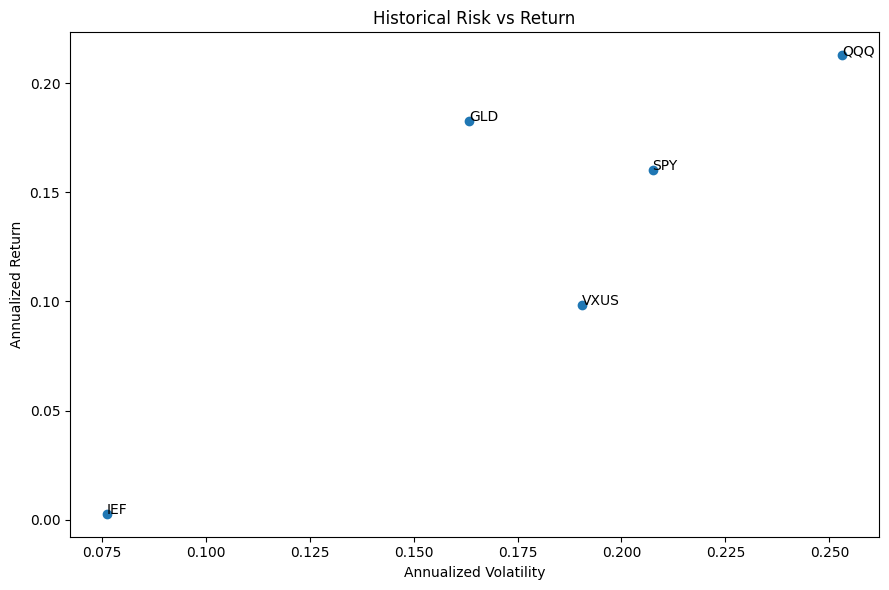

In [33]:
plt.figure(figsize=(9, 6))

plt.scatter(
    asset_summary["Annualized Volatility"],
    asset_summary["Annualized Return"]
)

for ticker in asset_summary.index:
    plt.annotate(
        ticker,
        (
            asset_summary.loc[ticker, "Annualized Volatility"],
            asset_summary.loc[ticker, "Annualized Return"]
        )
    )

plt.title("Historical Risk vs Return")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.tight_layout()
plt.show()

## Individual Asset Risk and Return
In the resulting graph, the assets exhibit notably different risk-return characteristics within the 2020-2025 sample period. QQQ produced the highest annualized return while also having the highest volatility which indicates that its strong historical return is associated with greater variability in daily returns. SPY produced a lower return than QQQ while having lower volatility. GLD produced a high annualized return, albeit lower than QQQ, while having lower volatility than both QQQ and SPY. In contrast to these, IEF produced the lowest return, almost close to zero, along with the lowest volatility. This demonstrated that lower historical volatility does not necessarily correspond to higher returns. VXUS occupied a middle position in terms of volatility but generated a considerably lower return than SPY and QQQ.

## Correlation and Diversification Analysis

To examine the potential for diversification across the selected assets,
the pairwise correlations between their daily returns are calculated.
Lower correlations indicate that two assets have historically moved less
closely together, which may provide greater diversification benefits when
combined in a portfolio.

In [34]:
correlation_matrix = daily_returns.corr()

correlation_matrix.round(2)

Ticker,GLD,IEF,QQQ,SPY,VXUS
Ticker,,,,,
GLD,1.00,0.31,0.14,0.13,0.26
IEF,0.31,1.00,-0.04,-0.08,-0.03
QQQ,0.14,-0.04,1.00,0.94,0.78
SPY,0.13,-0.08,0.94,1.00,0.86
VXUS,0.26,-0.03,0.78,0.86,1.00


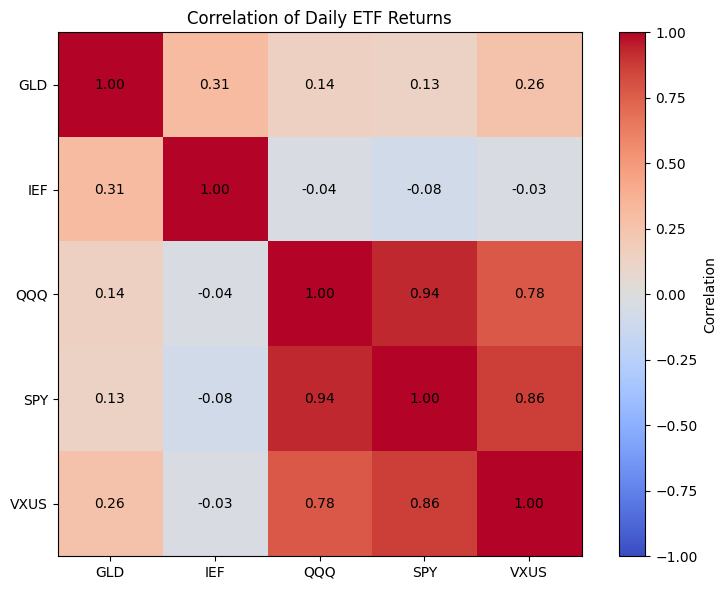

In [35]:
fig, ax = plt.subplots(figsize=(8, 6))

image = ax.imshow(
    correlation_matrix,
    vmin=-1,
    vmax=1,
    cmap="coolwarm"
)

ax.set_xticks(range(len(correlation_matrix.columns)))
ax.set_xticklabels(correlation_matrix.columns)

ax.set_yticks(range(len(correlation_matrix.index)))
ax.set_yticklabels(correlation_matrix.index)

for i in range(len(correlation_matrix.index)):
    for j in range(len(correlation_matrix.columns)):
        ax.text(
            j,
            i,
            f"{correlation_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.colorbar(image, ax=ax, label="Correlation")
plt.title("Correlation of Daily ETF Returns")
plt.tight_layout()
plt.show()

### Correlation Findings
The heatmap illustrates the highest correlation between SPY and QQQ, indicating that their daily returns tend to move closely together the most. This suggests that a combination of the two would result in less diversification. Similarly, VXUS high correlated with SPY and QQQ - although VXUS provides itnernational equity exposure, its returns still tend to move closely together with the US equity ETFs. As such, geographic diversification does not seem to eliminate common movement associated with equity markets. In comparison, IEF illustrates slightly negative correlation with al three equity ETFs - SPY, QQQ, and VXUS. This indiates that Treasury-bond returns behave differently from equity returns and could hence provide diversificate when combined with equities. GLD also indicated low positive correlation with the equity ETFs, suggesting potential diversification value in a multi-asset portfolio. 


## Portfolio Construction and Comparison

Three hypothetical portfolios are constructed to examine how adding
different asset exposures affects historical portfolio risk and return.

The portfolios use fixed target weights and range from an equity-focused
allocation to a more diversified multi-asset allocation.

In [36]:
portfolios = {
    "Equity-Focused": {
        "SPY": 0.50,
        "QQQ": 0.30,
        "VXUS": 0.20,
        "IEF": 0.00,
        "GLD": 0.00
    },

    "Equity + Bonds": {
        "SPY": 0.40,
        "QQQ": 0.25,
        "VXUS": 0.15,
        "IEF": 0.20,
        "GLD": 0.00
    },

    "Multi-Asset": {
        "SPY": 0.35,
        "QQQ": 0.20,
        "VXUS": 0.15,
        "IEF": 0.20,
        "GLD": 0.10
    }
}

In [38]:
for name, weights in portfolios.items():
    print(name, sum(weights.values()))

Equity-Focused 1.0
Equity + Bonds 1.0
Multi-Asset 1.0000000000000002


In [39]:
portfolio_daily_returns = pd.DataFrame(index=daily_returns.index)

In [40]:
for name, weights in portfolios.items():

    weight_series = pd.Series(weights)

    portfolio_daily_returns[name] = (
        daily_returns[weight_series.index] * weight_series
    ).sum(axis=1)

In [41]:
portfolio_daily_returns.head()

,Equity-Focused,Equity + Bonds,Multi-Asset
Date,,,
2020-01-03,-0.008985,-0.005820,-0.003657
2020-01-06,0.004128,0.003137,0.003673
2020-01-07,-0.001807,-0.001716,-0.001175
2020-01-08,0.005279,0.003813,0.002421
2020-01-09,0.006830,0.005648,0.004320


In [42]:
portfolio_mean_daily_returns = portfolio_daily_returns.mean()

In [43]:
portfolio_annualized_returns = (
    portfolio_mean_daily_returns * 252
)

In [44]:
portfolio_annualized_returns

Equity-Focused    0.163585
Equity + Bonds    0.132568
Multi-Asset       0.132197
dtype: float64

In [45]:
portfolio_daily_volatility = portfolio_daily_returns.std()

In [47]:
portfolio_annualized_volatility = (
    portfolio_daily_volatility * np.sqrt(252)
)

In [48]:
portfolio_annualized_volatility

Equity-Focused    0.209830
Equity + Bonds    0.168399
Multi-Asset       0.150114
dtype: float64

In [49]:
portfolio_summary = pd.DataFrame({
    "Annualized Return": portfolio_annualized_returns,
    "Annualized Volatility": portfolio_annualized_volatility
})

portfolio_summary

,Annualized Return,Annualized Volatility
Equity-Focused,0.163585,0.209830
Equity + Bonds,0.132568,0.168399
Multi-Asset,0.132197,0.150114


In [50]:
portfolio_summary_display = (
    portfolio_summary * 100
).round(2)

portfolio_summary_display.columns = [
    "Annualized Return (%)",
    "Annualized Volatility (%)"
]

portfolio_summary_display

,Annualized Return (%),Annualized Volatility (%)
Equity-Focused,16.36,20.98
Equity + Bonds,13.26,16.84
Multi-Asset,13.22,15.01


In [51]:
portfolio_cumulative_returns = (
    (1 + portfolio_daily_returns).cumprod() - 1
)

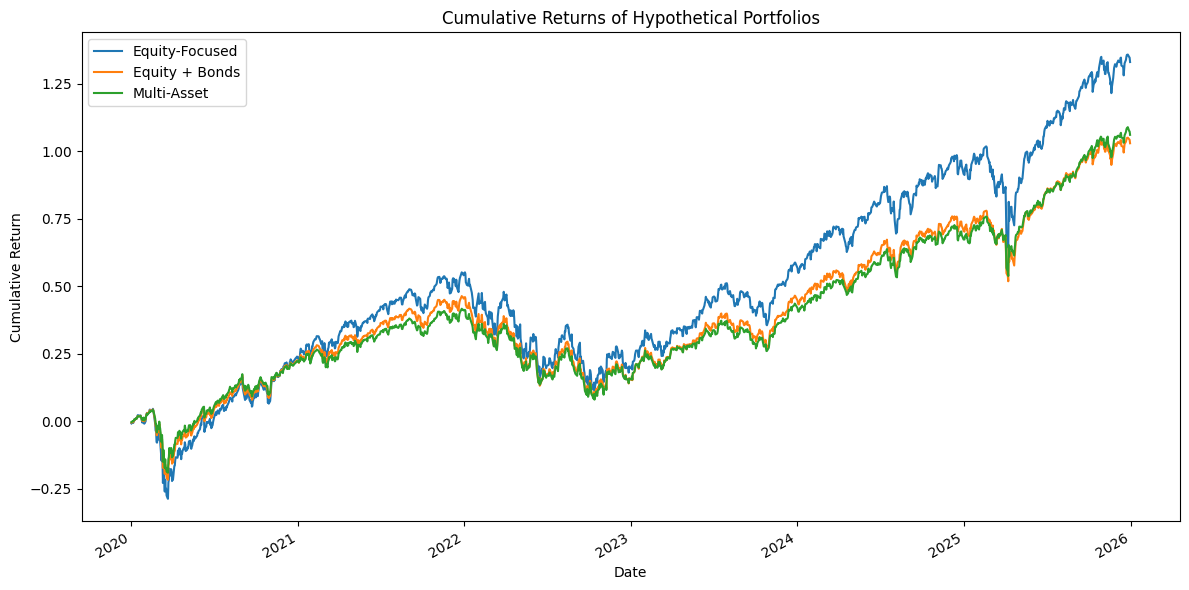

In [53]:
portfolio_cumulative_returns.plot(figsize=(12, 6))

plt.title("Cumulative Returns of Hypothetical Portfolios")
plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.tight_layout()
plt.show()

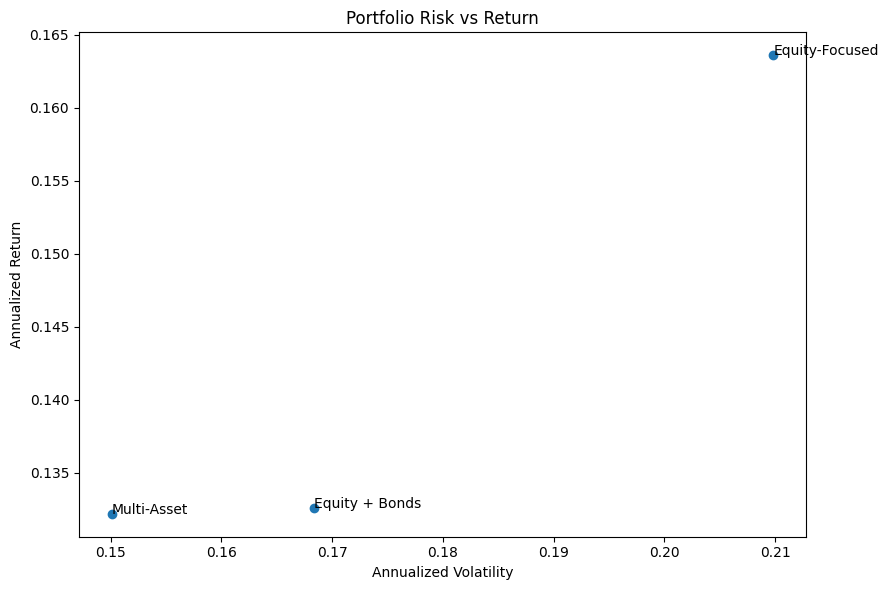

In [54]:
plt.figure(figsize=(9, 6))

plt.scatter(
    portfolio_summary["Annualized Volatility"],
    portfolio_summary["Annualized Return"]
)

for portfolio in portfolio_summary.index:
    plt.annotate(
        portfolio,
        (
            portfolio_summary.loc[
                portfolio,
                "Annualized Volatility"
            ],
            portfolio_summary.loc[
                portfolio,
                "Annualized Return"
            ]
        )
    )

plt.title("Portfolio Risk vs Return")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.tight_layout()
plt.show()

### Portfolio Comparison Findings
The Equity-Focused portfolio produced the highest annualized return at 16.36%, but it also had the highest annualized volatility at 20.98%. This reflects the greater concentration in equity assets, which were strongly correlated with one another during the sample period.
Adding Treasury-bond exposure reduced annualized volatility from 20.98% to 16.84%, while annualized return fell from 16.36% to 13.26%. This suggests that including IEF, which had very low correlations with the equity ETFs, helped reduce overall portfolio variability.
The Multi-Asset portfolio had the lowest annualized volatility at 15.01%, while maintaining an annualized return of 13.22%. Compared with the Equity + Bonds portfolio, its return was almost unchanged, but volatility fell further after gold exposure was introduced.
Overall, the results show that diversification across assets with different historical return relationships reduced portfolio volatility during the 2020–2025 sample period, although the most diversified portfolio did not produce the highest absolute return.